# FN6907 Group Assignment
Member:
- Hendrikus Hansen Witarsa
- Josiah Loke Wai Kit
- Stefanus Gunawan
- Viriya Gunawan Lim

### Calculation of discount factor Z(0, t) from the given term structure formula

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta

In [3]:
# Parameters
beta0 = 0.0408
beta1 = -0.0396
beta2 = -0.0511
tau = 1.614

# Nelson Siegel interest rate function
def nelson_siegel_rate(s, beta0, beta1, beta2, tau):
    term1 = beta0
    term2 = beta1 * (tau / s) * (1 - np.exp(-s / tau))
    term3 = beta2 * ((tau / s) * (1 - np.exp(-s / tau)) - np.exp(-s / tau))
    return term1 + term2 + term3

# Discount factor function
def discount_factor(s, beta0, beta1, beta2, tau):
    r = nelson_siegel_rate(s, beta0, beta1, beta2, tau)
    return np.exp(-r * s)

# Term structure of interest rate and discount factor for t=1,2,...,30
times = np.arange(1, 31)
print("Interest Rate and Discount Factor:")
print(" t     r(t)      Z(0,t)")
for t in times:
    r = nelson_siegel_rate(t, beta0, beta1, beta2, tau)
    z = discount_factor(t, beta0, beta1, beta2, tau)
    print(f"{t:>2d}   {r:.6f}   {z:.6f}")

Interest Rate and Discount Factor:
 t     r(t)      Z(0,t)
 1   0.000694   0.999307
 2   0.003604   0.992817
 3   0.007574   0.977534
 4   0.011559   0.954817
 5   0.015151   0.927045
 6   0.018236   0.896358
 7   0.020829   0.864330
 8   0.022990   0.832005
 9   0.024790   0.800030
10   0.026295   0.768780
11   0.027562   0.738461
12   0.028638   0.709171
13   0.029559   0.680949
14   0.030354   0.653798
15   0.031046   0.627699
16   0.031654   0.602626
17   0.032190   0.578546
18   0.032668   0.555423
19   0.033096   0.533221
20   0.033481   0.511906
21   0.033829   0.491441
22   0.034146   0.471795
23   0.034435   0.452933
24   0.034700   0.434825
25   0.034944   0.417442
26   0.035170   0.400753
27   0.035378   0.384731
28   0.035572   0.369350
29   0.035752   0.354584
30   0.035920   0.340408


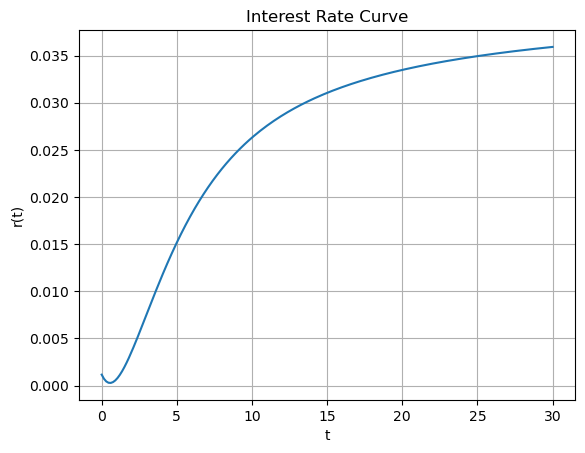

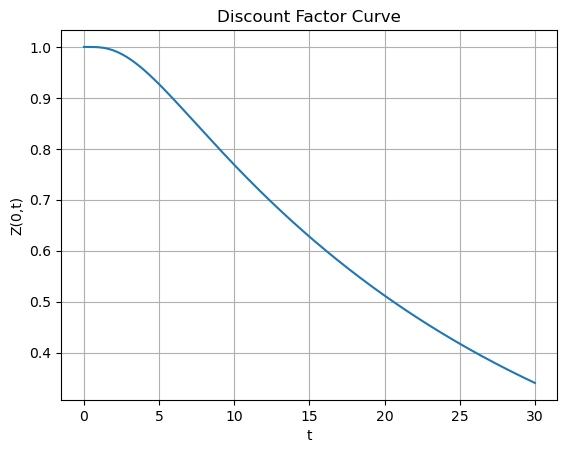

In [4]:
# Plot term structure of interest rate and discount factor
t_plot = np.linspace(0.01, 30, 200)
r_plot = [nelson_siegel_rate(t, beta0, beta1, beta2, tau) for t in t_plot]
z_plot = [discount_factor(t, beta0, beta1, beta2, tau) for t in t_plot]

plt.figure()
plt.plot(t_plot, r_plot)
plt.title("Interest Rate Curve")
plt.xlabel("t")
plt.ylabel("r(t)")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_plot, z_plot)
plt.title("Discount Factor Curve")
plt.xlabel("t")
plt.ylabel("Z(0,t)")
plt.grid()
plt.show()

### Calculation of survival probabilities Q(0,t)

Survival probability function

In [ ]:
def survival_probability(t, maturities, h):
    total = 0.0
    T_prev = 0.0
    for i in range(len(maturities)):
        T_i = maturities[i]
        h_i = h[i]
        if t <= T_i:
            total += (t - T_prev) * h_i
            return np.exp(-total)
        else:
            total += (T_i - T_prev) * h_i
            T_prev = T_i
    return np.exp(-total)

### Calculation of $h_i$ using the Newton-Raphson algorithm

This section bootstraps the piecewise-constant forward default rates $h_1,\dots,h_M$ from the market CDS spreads.

For each maturity $T_i$, we solve
$V_i(h_i)=0$
using Newton-Raphson, while keeping $h_1,\dots,h_{i-1}$ fixed from the earlier bootstrap steps.

Key idea:
- The survival curve is piecewise exponential.
- For the $i$-th CDS, only the unknown segment $h_i$ is solved.
- We use the closed-form derivative of $Q(0,t)$ with respect to $h_i$:
$\frac{\partial Q(0,t)}{\partial h_i}=
\begin{cases}
0, & t \le T_{i-1},\\
-(t-T_{i-1})Q(0,t), & T_{i-1}<t\le T_i.
\end{cases}$


In [7]:
from datetime import date, timedelta
import math
import pandas as pd

# Market CDS data
valuation_date = date(2014, 2, 28)
recovery_rate = 0.45
m = 12                 # monthly subintervals
tol = 1e-6             # Newton-Raphson tolerance
x0 = 0.01              # initial guess

market_cds = [
    ("6M",  date(2014, 9, 20), 103.07),
    ("1Y",  date(2015, 3, 20), 104.68),
    ("2Y",  date(2016, 3, 20), 106.74),
    ("3Y",  date(2017, 3, 20), 110.31),
    ("4Y",  date(2018, 3, 20), 113.38),
    ("5Y",  date(2019, 3, 20), 116.98),
    ("7Y",  date(2021, 3, 20), 128.78),
    ("10Y", date(2024, 3, 20), 143.51),
    ("20Y", date(2034, 3, 20), 159.43),
    ("30Y", date(2044, 3, 20), 164.13),
]

def modified_following_weekend(d):
    if d.weekday() == 5:   # Saturday
        return d + timedelta(days=2)
    if d.weekday() == 6:   # Sunday
        return d + timedelta(days=1)
    return d

def act360(d1, d2):
    return (d2 - d1).days / 360.0

# Handle t = 0 safely
def nelson_siegel_rate_safe(s, beta0, beta1, beta2, tau):
    if np.isscalar(s):
        if s == 0:
            return beta0 + beta1
        return nelson_siegel_rate(s, beta0, beta1, beta2, tau)
    s = np.asarray(s, dtype=float)
    out = np.empty_like(s)
    mask = (s == 0)
    out[mask] = beta0 + beta1
    out[~mask] = nelson_siegel_rate(s[~mask], beta0, beta1, beta2, tau)
    return out

def discount_factor_safe(t, beta0, beta1, beta2, tau):
    if np.isscalar(t) and t == 0:
        return 1.0
    r = nelson_siegel_rate_safe(t, beta0, beta1, beta2, tau)
    return np.exp(-r * np.asarray(t))

# Roll maturity dates and convert spreads to decimals
market_cds_rolled = [
    (tenor, modified_following_weekend(mat_date), spread_bp / 10000.0)
    for tenor, mat_date, spread_bp in market_cds
]

maturities = [act360(valuation_date, mat_date) for _, mat_date, _ in market_cds_rolled]
spreads = [spread for _, _, spread in market_cds_rolled]

def future_standard_payment_dates(maturity_date):
    dates = []
    y = valuation_date.year
    while y <= maturity_date.year:
        for month, day in [(3, 20), (6, 20), (9, 20), (12, 20)]:
            d = modified_following_weekend(date(y, month, day))
            if valuation_date < d <= maturity_date:
                dates.append(d)
        y += 1
    return sorted(dates)

def cds_schedule(maturity_date):
    pay_dates = future_standard_payment_dates(maturity_date)
    pay_times = [act360(valuation_date, d) for d in pay_dates]
    deltas = []
    prev = valuation_date
    for d in pay_dates:
        deltas.append(act360(prev, d))
        prev = d
    return pay_dates, pay_times, deltas

def survival_probability_piecewise(t, maturities, h_values):
    total = 0.0
    T_prev = 0.0
    for T_i, h_i in zip(maturities, h_values):
        if t <= T_i + 1e-15:
            total += (t - T_prev) * h_i
            return np.exp(-total)
        total += (T_i - T_prev) * h_i
        T_prev = T_i
    return np.exp(-total)

def dQ_dhi(t, i, maturities, h_values):
    T_prev = 0.0 if i == 0 else maturities[i - 1]
    if t <= T_prev + 1e-15:
        return 0.0
    q = survival_probability_piecewise(t, maturities, h_values)
    return -(t - T_prev) * q

def cds_equation(hi, i, known_h, maturities, spreads, recovery_rate, m):
    h_values = known_h + [hi]
    T_i = maturities[i]

    # Protection leg approximation
    K_i = math.ceil(m * T_i)
    grid = [k * T_i / K_i for k in range(K_i + 1)]

    protection_leg = 0.0
    for k in range(1, K_i + 1):
        s_prev, s_curr = grid[k - 1], grid[k]
        Z_avg = discount_factor_safe(s_prev, beta0, beta1, beta2, tau) + discount_factor_safe(s_curr, beta0, beta1, beta2, tau)
        dq = survival_probability_piecewise(s_prev, maturities, h_values) - survival_probability_piecewise(s_curr, maturities, h_values)
        protection_leg += Z_avg * dq
    protection_leg *= (1 - recovery_rate) / 2.0

    # Premium leg approximation
    maturity_date = market_cds_rolled[i][1]
    _, pay_times, deltas = cds_schedule(maturity_date)

    premium_leg = 0.0
    prev_t = 0.0
    for t_n, delta_n in zip(pay_times, deltas):
        premium_leg += delta_n * discount_factor_safe(t_n, beta0, beta1, beta2, tau) * (
            survival_probability_piecewise(prev_t, maturities, h_values) +
            survival_probability_piecewise(t_n, maturities, h_values)
        )
        prev_t = t_n
    premium_leg *= spreads[i] / 2.0

    return protection_leg - premium_leg

def cds_equation_derivative(hi, i, known_h, maturities, spreads, recovery_rate, m):
    h_values = known_h + [hi]
    T_i = maturities[i]

    K_i = math.ceil(m * T_i)
    grid = [k * T_i / K_i for k in range(K_i + 1)]

    d_protection_leg = 0.0
    for k in range(1, K_i + 1):
        s_prev, s_curr = grid[k - 1], grid[k]
        Z_avg = discount_factor_safe(s_prev, beta0, beta1, beta2, tau) + discount_factor_safe(s_curr, beta0, beta1, beta2, tau)
        d_protection_leg += Z_avg * (
            dQ_dhi(s_prev, i, maturities, h_values) - dQ_dhi(s_curr, i, maturities, h_values)
        )
    d_protection_leg *= (1 - recovery_rate) / 2.0

    maturity_date = market_cds_rolled[i][1]
    _, pay_times, deltas = cds_schedule(maturity_date)

    d_premium_leg = 0.0
    prev_t = 0.0
    for t_n, delta_n in zip(pay_times, deltas):
        d_premium_leg += delta_n * discount_factor_safe(t_n, beta0, beta1, beta2, tau) * (
            dQ_dhi(prev_t, i, maturities, h_values) +
            dQ_dhi(t_n, i, maturities, h_values)
        )
        prev_t = t_n
    d_premium_leg *= spreads[i] / 2.0

    return d_protection_leg - d_premium_leg

def solve_hi_newton(i, known_h, maturities, spreads, recovery_rate, m, x0=0.01, tol=1e-6, max_iter=100):
    x = x0
    history = []

    for iteration in range(max_iter):
        fx = cds_equation(x, i, known_h, maturities, spreads, recovery_rate, m)
        dfx = cds_equation_derivative(x, i, known_h, maturities, spreads, recovery_rate, m)
        history.append((iteration, x, fx, dfx))

        if abs(fx) < tol:
            return x, history

        if abs(dfx) < 1e-12:
            raise ValueError(f"Derivative too small at iteration {iteration} for h_{i+1}")

        x_new = x - fx / dfx

        # keep hazard rate positive
        if x_new <= 0:
            x_new = x / 2.0

        x = x_new

    return x, history

# Bootstrap all h_i
h_values = []
histories = []

for i in range(len(maturities)):
    h_i, history_i = solve_hi_newton(
        i=i,
        known_h=h_values,
        maturities=maturities,
        spreads=spreads,
        recovery_rate=recovery_rate,
        m=m,
        x0=x0,
        tol=tol
    )
    h_values.append(h_i)
    histories.append(history_i)

# Display results
h_table = pd.DataFrame({
    "Tenor": [x[0] for x in market_cds_rolled],
    "Maturity (years)": maturities,
    "Market Spread": spreads,
    "h_i": h_values,
    "Check V_i(h_i)": [
        cds_equation(h_values[i], i, h_values[:i], maturities, spreads, recovery_rate, m)
        for i in range(len(h_values))
    ],
    "Newton Iterations": [len(hist) for hist in histories]
})

print("Bootstrapped forward default rates h_i:")
display(h_table)


Bootstrapped forward default rates h_i:


,Tenor,Maturity (years),Market Spread,h_i,Check V_i(h_i),Newton Iterations
0,6M,0.572222,0.010307,0.018740,-4.243787e-11,3
1,1Y,1.069444,0.010468,0.019369,-3.164529e-11,3
2,2Y,2.088889,0.010674,0.019791,-6.465943e-10,3
3,3Y,3.100000,0.011031,0.021416,-1.112061e-09,3
4,4Y,4.113889,0.011338,0.022386,-1.484479e-09,3
5,5Y,5.127778,0.011698,0.024139,-2.383300e-09,3
6,7Y,7.163889,0.012878,0.029763,-1.274358e-07,3
7,10Y,10.202778,0.014351,0.034542,-1.894276e-12,4
8,20Y,20.347222,0.015943,0.034676,-8.204966e-09,4
9,30Y,30.497222,0.016413,0.035232,-4.496878e-09,4


Updated Survival Probability:
 t    Q(0,t)
 0   1.000000
 1   0.981171
 2   0.961971
 3   0.941724
 4   0.920967
 5   0.899181
 6   0.873441
 7   0.847828
 8   0.819684
 9   0.791854
10   0.764969
11   0.738918
12   0.713735
13   0.689410
14   0.665914
15   0.643218
16   0.621297
17   0.600122
18   0.579669
19   0.559913
20   0.540830
21   0.522209
22   0.504130
23   0.486678
24   0.469830
25   0.453565
26   0.437863
27   0.422705
28   0.408072
29   0.393945
30   0.380307


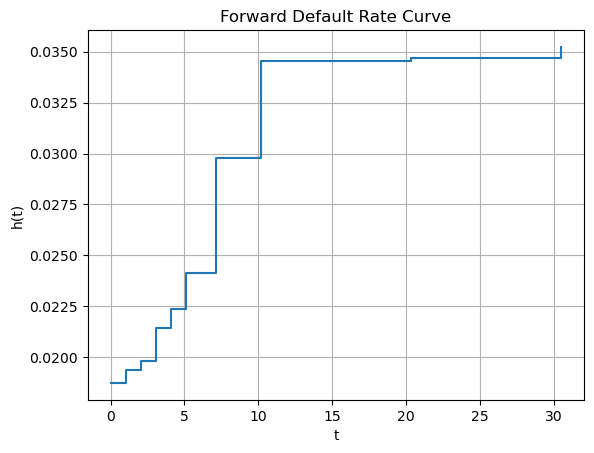

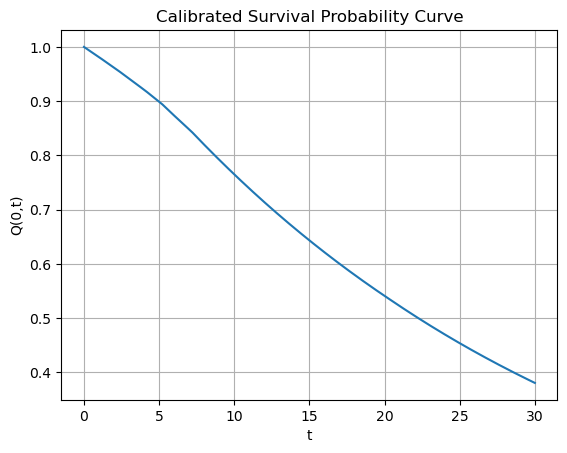

In [8]:
# Update the survival curve using calibrated h_i
times = np.arange(0, 31)
q_calibrated = [survival_probability_piecewise(t, maturities, h_values) for t in times]

print("Updated Survival Probability:")
print(" t    Q(0,t)")
for t, q in zip(times, q_calibrated):
    print(f"{t:2d}   {q:.6f}")

# Plot piecewise-constant forward default rates h(t)
plt.figure()
plt.step([0] + maturities, [h_values[0]] + h_values, where='post')
plt.title("Forward Default Rate Curve")
plt.xlabel("t")
plt.ylabel("h(t)")
plt.grid()
plt.show()

# Plot calibrated survival probability curve
t_plot = np.linspace(0, 30, 300)
q_plot = [survival_probability_piecewise(t, maturities, h_values) for t in t_plot]

plt.figure()
plt.plot(t_plot, q_plot)
plt.title("Calibrated Survival Probability Curve")
plt.xlabel("t")
plt.ylabel("Q(0,t)")
plt.grid()
plt.show()

### Mark-to-Market Value of Non-Standard CDS

In [9]:
def roll_date(d):
    """
    Apply modified following convention:
    if d falls on Saturday -> move to Monday
    if d falls on Sunday -> move to Monday
    """
    if d.weekday() == 5:  # Saturday
        return d + timedelta(days=2)
    if d.weekday() == 6:  # Sunday
        return d + timedelta(days=1)
    return d

def add_months(d, months):
    """Add whole months to a date, clamping day-of-month when needed."""
    month_index = d.month - 1 + months
    year = d.year + month_index // 12
    month = month_index % 12 + 1

    if month == 12:
        first_next_month = date(year + 1, 1, 1)
    else:
        first_next_month = date(year, month + 1, 1)

    last_day = (first_next_month - timedelta(days=1)).day
    day = min(d.day, last_day)
    return date(year, month, day)

def standard_maturity(trade_date, years):
    """
    Find the first standard maturity date (20 Mar/Jun/Sep/Dec)
    that is AT LEAST 'years' years after trade_date
    """
    standard_months = [3, 6, 9, 12]  # Mar, Jun, Sep, Dec
    target_months = int(round(years * 12))
    target = add_months(trade_date, target_months)

    # Find first standard date >= target
    for year in [target.year, target.year + 1]:
        for month in standard_months:
            candidate = date(year, month, 20)
            if candidate >= target:
                return roll_date(candidate)

def generate_payment_dates(effective_date, maturity_date, months_per_payment=3): # for non-standard CDS
    """
    Generate all payment dates from effective_date to maturity_date
    Payments occur every 3 months (quarterly)
    Apply weekend roll to each date
    """
    dates = []
    d = effective_date
    while d <= maturity_date:
        dates.append(roll_date(d))
        d = add_months(d, months_per_payment)
    return dates

def dcf(date1, date2):
    """
    Actual/360 day count fraction
    """
    return (date2 - date1).days / 360

In [10]:
def protection_leg(ns_maturity_years, ns_recovery, 
                   all_maturities, h_values, m=12):
    """
    Protection leg for non-standard CDS.
    ns_maturity_years : maturity in years from valuation date
    """
    K = int(np.ceil(m * ns_maturity_years))
    epsilon = ns_maturity_years / K

    prot = 0.0
    for k in range(1, K + 1):
        s_prev = (k - 1) * epsilon
        s_curr = k * epsilon
        Z_prev = 1.0 if s_prev == 0 else discount_factor_safe(
                     s_prev, beta0, beta1, beta2, tau)
        Z_curr = discount_factor_safe(s_curr, beta0, beta1, beta2, tau)
        Q_prev = survival_probability_piecewise(
                     s_prev, all_maturities, h_values)
        Q_curr = survival_probability_piecewise(
                     s_curr, all_maturities, h_values)
        prot += (Z_prev + Z_curr) * (Q_prev - Q_curr)

    return prot * (1 - ns_recovery) / 2

def rpv01_seasoned(t_minus1, t0, future_dates,
                   valuation_date, all_maturities, h_values):
    """
    RPVO1 for a seasoned (mid-life) CDS.
    
    t_minus1    : last payment date before today (date object)
    t0          : first payment date after today (date object)
    future_dates: all payment dates after today [t0, t1, ..., tN]
    """
    # Convert t0 to years
    t0_yrs = (t0 - valuation_date).days / 365.25
    Z_t0   = discount_factor_safe(t0_yrs, beta0, beta1, beta2, tau)
    Q_t0   = survival_probability_piecewise(
                 t0_yrs, all_maturities, h_values)

    # Term A: Delta(t_-1, 0) * Z(t0) * (1 - Q(t0))
    # Note: Delta(t_-1, 0) means from t_-1 to valuation date
    delta_A = dcf(t_minus1, valuation_date)   # Actual/360
    term_A  = delta_A * Z_t0 * (1 - Q_t0)

    # Term B: 0.5 * Delta(0, t0) * Z(t0) * (1 - Q(t0))
    delta_B = dcf(valuation_date, t0)         # Actual/360
    term_B  = 0.5 * delta_B * Z_t0 * (1 - Q_t0)

    # Term C: Delta(t_-1, t0) * Z(t0) * Q(t0)
    delta_C = dcf(t_minus1, t0)              # Actual/360
    term_C  = delta_C * Z_t0 * Q_t0

    # Term D: 0.5 * sum over future periods
    # Note: first interval is from t0 to t1, using Q(t0) and Q(t1)
    term_D = 0.0
    dates_for_D = future_dates  # [t0, t1, t2, ..., tN]
    for n in range(1, len(dates_for_D)):
        t_prev_date = dates_for_D[n - 1]
        t_curr_date = dates_for_D[n]
        delta_n = dcf(t_prev_date, t_curr_date)
        t_prev_yrs = (t_prev_date - valuation_date).days / 365.25
        t_curr_yrs = (t_curr_date - valuation_date).days / 365.25
        Z_n  = discount_factor_safe(t_curr_yrs, beta0, beta1, beta2, tau)
        Q_prev = survival_probability_piecewise(
                     t_prev_yrs, all_maturities, h_values)
        Q_curr = survival_probability_piecewise(
                     t_curr_yrs, all_maturities, h_values)
        term_D += delta_n * Z_n * (Q_prev + Q_curr)
    term_D *= 0.5

    return term_A + term_B + term_C + term_D

def mtm_seasoned_cds(protection, rpv01, ns_spread,
                     t_minus1, t0, valuation_date,
                     all_maturities, h_values, face_value):
    """
    Compute full MTM, accrued interest, and clean MTM.
    """
    # Full MTM (per unit notional)
    full_mtm_unit = protection - ns_spread * rpv01

    # Accrued interest
    # = spread * Delta(t_-1, today) * (fraction of next coupon accrued)
    t0_yrs    = (t0 - valuation_date).days / 365.25
    Z_t0      = discount_factor_safe(t0_yrs, beta0, beta1, beta2, tau)
    Q_t0      = survival_probability_piecewise(
                    t0_yrs, all_maturities, h_values)
    delta_acc = dcf(t_minus1, valuation_date)   # accrued period
    accrued   = ns_spread * delta_acc

    # Clean MTM = Full MTM - Accrued Interest
    clean_mtm_unit = full_mtm_unit - accrued

    # Scale by face value
    return {
        "Protection Leg ($)": protection * face_value,
        "Premium Leg ($)":    ns_spread * rpv01 * face_value,
        "Full MTM ($)":       full_mtm_unit * face_value,
        "Accrued Interest ($)": accrued * face_value,
        "Clean MTM ($)":      clean_mtm_unit * face_value,
    }

In [11]:
# Non-standard CDS parameters
ns_effective  = date(2012, 5, 15)
ns_maturity   = date(2042, 5, 15)
ns_spread     = 170 / 10000        # 170 bp
ns_recovery   = 0.60
face_value    = 100_000_000        # $100M

# Get payment dates
all_ns_dates  = generate_payment_dates(ns_effective, ns_maturity)
past_dates    = [d for d in all_ns_dates if d <= valuation_date]
future_dates  = [d for d in all_ns_dates if d > valuation_date]

t_minus1      = past_dates[-1]
t0            = future_dates[0]

# Maturity in years
ns_mat_years  = (ns_maturity - valuation_date).days / 365.25

# Compute legs
prot  = protection_leg(ns_mat_years, ns_recovery, maturities, h_values)
rpv01 = rpv01_seasoned(t_minus1, t0, future_dates,
                        valuation_date, maturities, h_values)

# Compute MTM
results = mtm_seasoned_cds(prot, rpv01, ns_spread,
                            t_minus1, t0, valuation_date,
                            maturities, h_values, face_value)

for k, v in results.items():
    print(f"{k:30s}: ${v:>20,.2f}")

Protection Leg ($)            : $       16,599,748.22
Premium Leg ($)               : $       24,138,762.13
Full MTM ($)                  : $       -7,539,013.91
Accrued Interest ($)          : $           51,944.44
Clean MTM ($)                 : $       -7,590,958.36
